# 1. Standard Scalling 

standard scalling is a technique to standardize the features by removing the mean and scaling to unit variance

The formula for standard scalling is:

$$ Z = (x - mean(x)) / std(x) $$

In [9]:
 # Import Libraries
import pandas as pd
from sklearn.preprocessing import StandardScaler,MinMaxScaler,MaxAbsScaler,RobustScaler
from sklearn.model_selection import train_test_split

- If your data is normally distributed than ML model will work well

- Data transfomation is a process where we do convert data into  modeified usuallyfrom big to small level

# Standardization

- Standard scalor(-3 to 3)
- Min max scalar(0-1)
- Max Absolute scaler(-1 to 1)

----

#  Transformers
- Quantile transformer(to uniform)

- Power transformer


In [10]:
# Make an exampe Data set for standardization
df={"age":[23,45,56,67,89],
   "height":[5.1,5.5,5.9,6.1,6.3],
   "weight":[120,150,170,180,200]}

# Create a DataFrame
df=pd.DataFrame(df)

# Display the DataFrame



df.head()

,age,height,weight
0,23,5.1,120
1,45,5.5,150
2,56,5.9,170
3,67,6.1,180
4,89,6.3,200


In [11]:
scaler=StandardScaler()
scaled=scaler.fit_transform(df)
scaled

# convert the scaled data to a DataFrame
scaled_df=pd.DataFrame(scaled,columns=df.columns)
# Display the scaled DataFrame
scaled_df.head()

,age,height,weight
0,-1.5,-1.578410,-1.613118
1,-0.5,-0.649934,-0.513265
2,0.0,0.278543,0.219971
3,0.5,0.742781,0.586588
4,1.5,1.207020,1.319824


# Min - Max Scaler

In [12]:
min_max_scaler=MinMaxScaler()
# Fit and transform the data
scaled_data=min_max_scaler.fit_transform(df)
# Convert the scaled data to a DataFrame
scaled_df=pd.DataFrame(scaled_data,columns=df.columns)
# Display the scaled DataFrame
scaled_df.head()

,age,height,weight
0,0.000000,0.000000,0.000
1,0.333333,0.333333,0.375
2,0.500000,0.666667,0.625
3,0.666667,0.833333,0.750
4,1.000000,1.000000,1.000


# Absolute Scaler 

In [13]:
absolute_scaler=MaxAbsScaler()
scaled=scaler.fit_transform(df)
scaled

# convert the scaled data to a DataFrame
scaled_df_abs=pd.DataFrame(scaled,columns=df.columns)
# Display the scaled DataFrame
scaled_df_abs.head()

,age,height,weight
0,-1.5,-1.578410,-1.613118
1,-0.5,-0.649934,-0.513265
2,0.0,0.278543,0.219971
3,0.5,0.742781,0.586588
4,1.5,1.207020,1.319824


# RObust Scaler

In [14]:
R_scaler=RobustScaler()
R_scaled=scaler.fit_transform(df)
R_scaled

# convert the scaled data to a DataFrame
scaled_df_R=pd.DataFrame(scaled,columns=df.columns)
# Display the scaled DataFrame
scaled_df_R.head()

,age,height,weight
0,-1.5,-1.578410,-1.613118
1,-0.5,-0.649934,-0.513265
2,0.0,0.278543,0.219971
3,0.5,0.742781,0.586588
4,1.5,1.207020,1.319824


# Most Used Scaler 
- If your Algorithm handles minus values than standard scaler is the best
- If your Algorithm do not handles minus values than Min-Max  scaler is the best

----
# Transformation of the data 

In [5]:
# import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
# Generate non-normal data (exponential distribution)
np.random.seed(0)
data = np.random.exponential(scale=2, size=1000)
# Create a DataFrame
df = pd.DataFrame(data, columns=['value'])
# Display the first few rows of the DataFrame
df.head()
df.shape

(1000, 1)

<Axes: xlabel='value', ylabel='Count'>

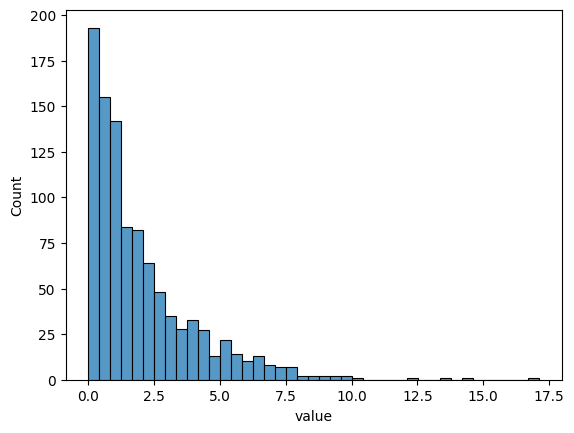

In [7]:
sns.histplot(df['value'])

In [8]:
# Let's transfrom 
from sklearn.preprocessing import PowerTransformer
# apply power transformer
pt = PowerTransformer(method='yeo-johnson')
# Fit and transform the data
transformed_data = pt.fit_transform(df[['value']])
# Convert the transformed data to a DataFrame
transformed_data = pd.DataFrame(transformed_data, columns=['value'])
# Display the first few rows of the transformed DataFrame
transformed_data.head()

,value
0,0.179335
1,0.677331
2,0.339698
3,0.167607
4,-0.202107


<Axes: xlabel='value', ylabel='Count'>

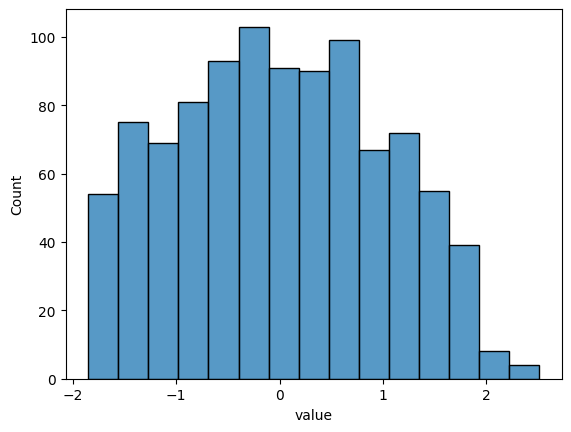

In [9]:
sns.histplot(transformed_data['value'])

In [10]:
# now using box-cox method
from sklearn.preprocessing import PowerTransformer
pt= PowerTransformer(method='box-cox')
# Fit and transform the data
transformed_data_B= pt.fit_transform(df[['value']])
# Convert the transformed data to a DataFrame
transformed_data_B = pd.DataFrame(transformed_data_B, columns=['value'])
# Display the first few rows of the transformed DataFrame
transformed_data_B.head()


,value
0,0.158969
1,0.602906
2,0.298068
3,0.148897
4,-0.164776


<Axes: xlabel='value', ylabel='Count'>

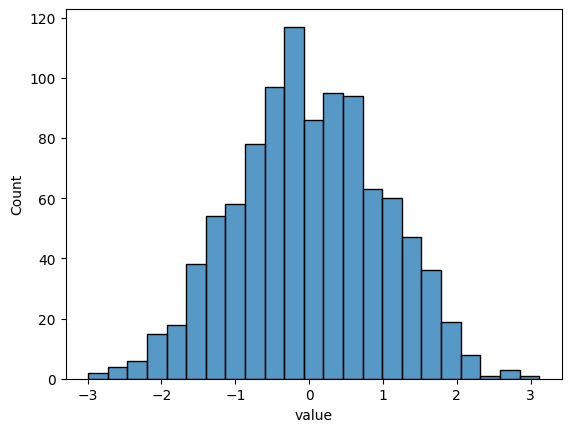

In [11]:
sns.histplot(transformed_data_B['value'])


In [18]:
 #Power transformer
from sklearn.preprocessing import PowerTransformer


# Generate non-normal data (exponential distribution)
np.random.seed(0)
data = np.random.exponential(scale=2, size=1000)
# Create a DataFrame
df = pd.DataFrame(data, columns=['value'])
# Display the first few rows of the DataFrame
df.head()

pt_boxcox= PowerTransformer(method='box-cox',standardize=False)   # data must be positive for box-cox
pt_yeo= PowerTransformer(method='yeo-johnson')  # data can be negative for yeo-johnson

df['Box-Cox'] = pt_boxcox.fit_transform(df[['value']]+1)  # Adding 1 to make data positive for Box-Cox
# Fit and transform the data using Yeo-Johnson method
df['Yeo-Johnson'] = pt_yeo.fit_transform(df[['value']])

df.head()




,value,Box-Cox,Yeo-Johnson
0,1.591749,0.787485,0.179335
1,2.511862,0.980233,0.677331
2,1.846446,0.849553,0.339698
3,1.574402,0.782945,0.167607
4,1.102097,0.639848,-0.202107


In [22]:
# Quantile Transformation
from sklearn.preprocessing import QuantileTransformer
qt_transformer = QuantileTransformer(output_distribution='normal')
# Fit and transform the data
df['qt_transformed_data'] = qt_transformer.fit_transform(df[['value']])
df.head()

,value,Box-Cox,Yeo-Johnson,qt_transformed_data
0,1.591749,0.787485,0.179335,0.162552
1,2.511862,0.980233,0.677331,0.587964
2,1.846446,0.849553,0.339698,0.286135
3,1.574402,0.782945,0.167607,0.157469
4,1.102097,0.639848,-0.202107,-0.154930


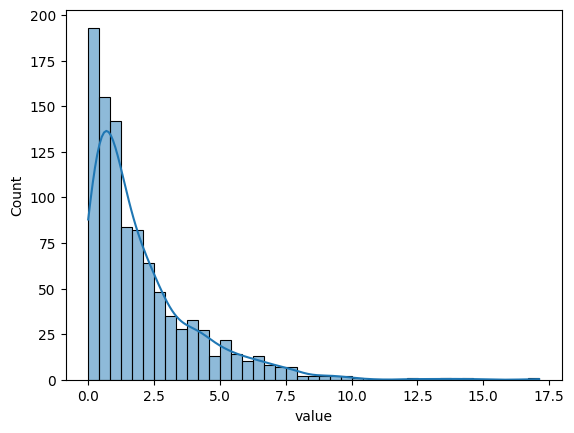

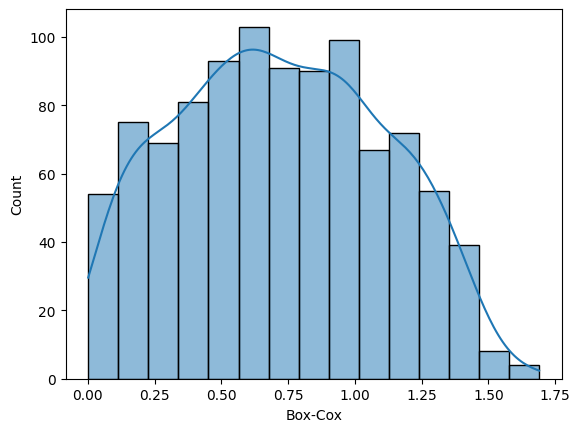

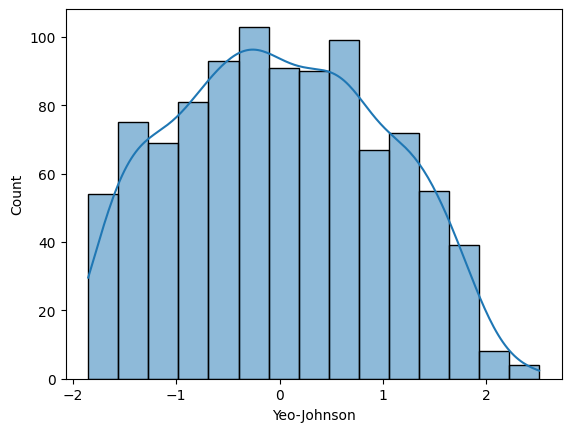

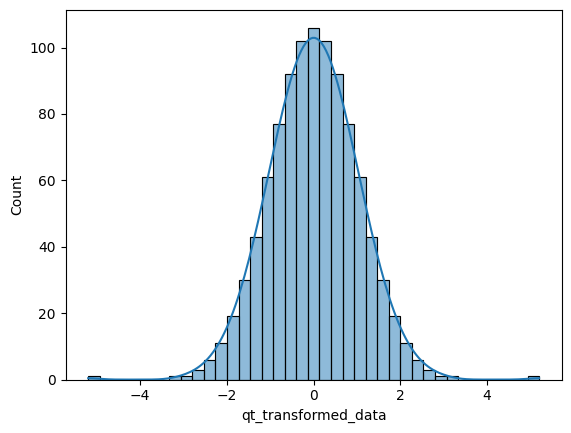

In [23]:
for col in df.columns:
    sns.histplot(df[col], kde=True, label=col)
    plt.show()

---

 # L2 Normalizer 

Rescales each samples(row) to have unit norm 

1. Z-score Normalization


    1.standard scalar
2. Min -Max scaling

# Log Transformation


In [1]:
import pandas as pd
import numpy as np

In [9]:
# Exmple skewed dataset

df={"values":[1,5,10,20,50,100,200,500,1000,2000,3500,5000,10000]}
df=pd.DataFrame(df)
df


,values
0,1
1,5
2,10
3,20
4,50
5,100
6,200
7,500
8,1000
9,2000


<Axes: xlabel='values', ylabel='Count'>

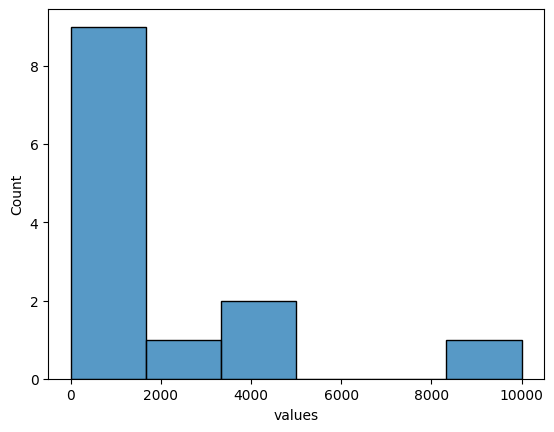

In [10]:
import seaborn as sns
sns.histplot(df['values'])

In [11]:
df['Log_Transformation']=np.log(df['values'])
df

,values,Log_Transformation
0,1,0.000000
1,5,1.609438
2,10,2.302585
3,20,2.995732
4,50,3.912023
5,100,4.605170
6,200,5.298317
7,500,6.214608
8,1000,6.907755
9,2000,7.600902


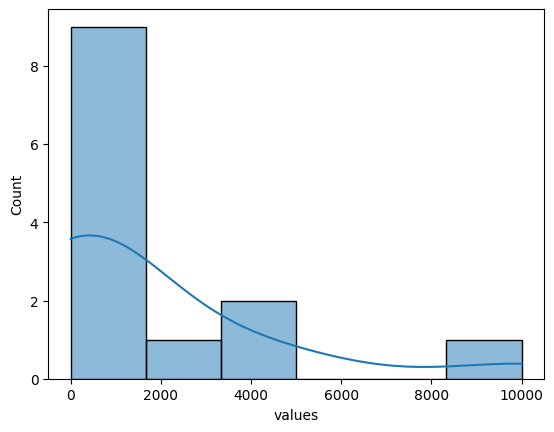

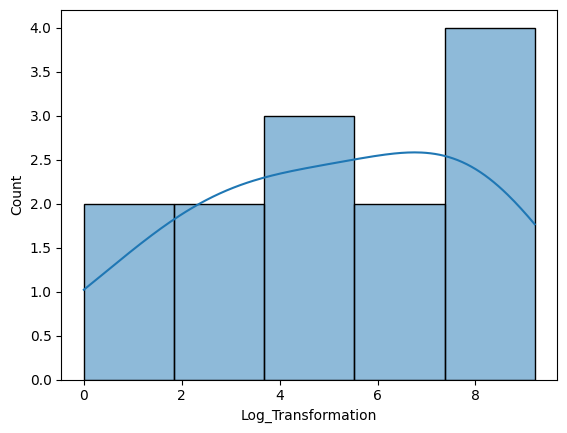

In [13]:
# Hist plot for all
import matplotlib.pyplot as plt

for col in df.columns:
    sns.histplot(df[col],kde=True)
    plt.show()